# 5. YOLO Segmentazione (Riconoscimento Giocatori)
Questo notebook scarica il Foundation Model YOLO11-Seg pre-addestrato su COCO 
per isolare la classe 'Person' (Giocatori e Arbitri) ed escluderli dal Green Screen.

In [ ]:
import os, cv2, torch, shutil
import numpy as np
from pathlib import Path
from ultralytics import YOLO
import matplotlib.pyplot as plt

BASE = Path('/teamspace/studios/this_studio/project-sbs')
WEIGHTS_DIR = BASE / 'model_weights' / 'yolo_seg'
WEIGHTS_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH = WEIGHTS_DIR / 'yolo11n-seg.pt'

if not MODEL_PATH.exists():
    print('⬇️ Scaricamento pesi YOLO11-Seg...')
    temp_model = YOLO('yolo11n-seg.pt')
    downloaded = Path(temp_model.ckpt_path) if getattr(temp_model, 'ckpt_path', None) else Path('yolo11n-seg.pt')
    if downloaded.exists():
        shutil.move(str(downloaded), str(MODEL_PATH))
        print(f'✅ Salvati in {MODEL_PATH}')
else:
    print(f'✅ Pesi trovati in {MODEL_PATH}')

person_model = YOLO(str(MODEL_PATH))
print('✅ Modello YOLO-Seg pronto all\'uso!')

✅ Pesi trovati in /teamspace/studios/this_studio/project-sbs/model_weights/yolo_seg/yolo11n-seg.pt
✅ Modello YOLO-Seg pronto all'uso!


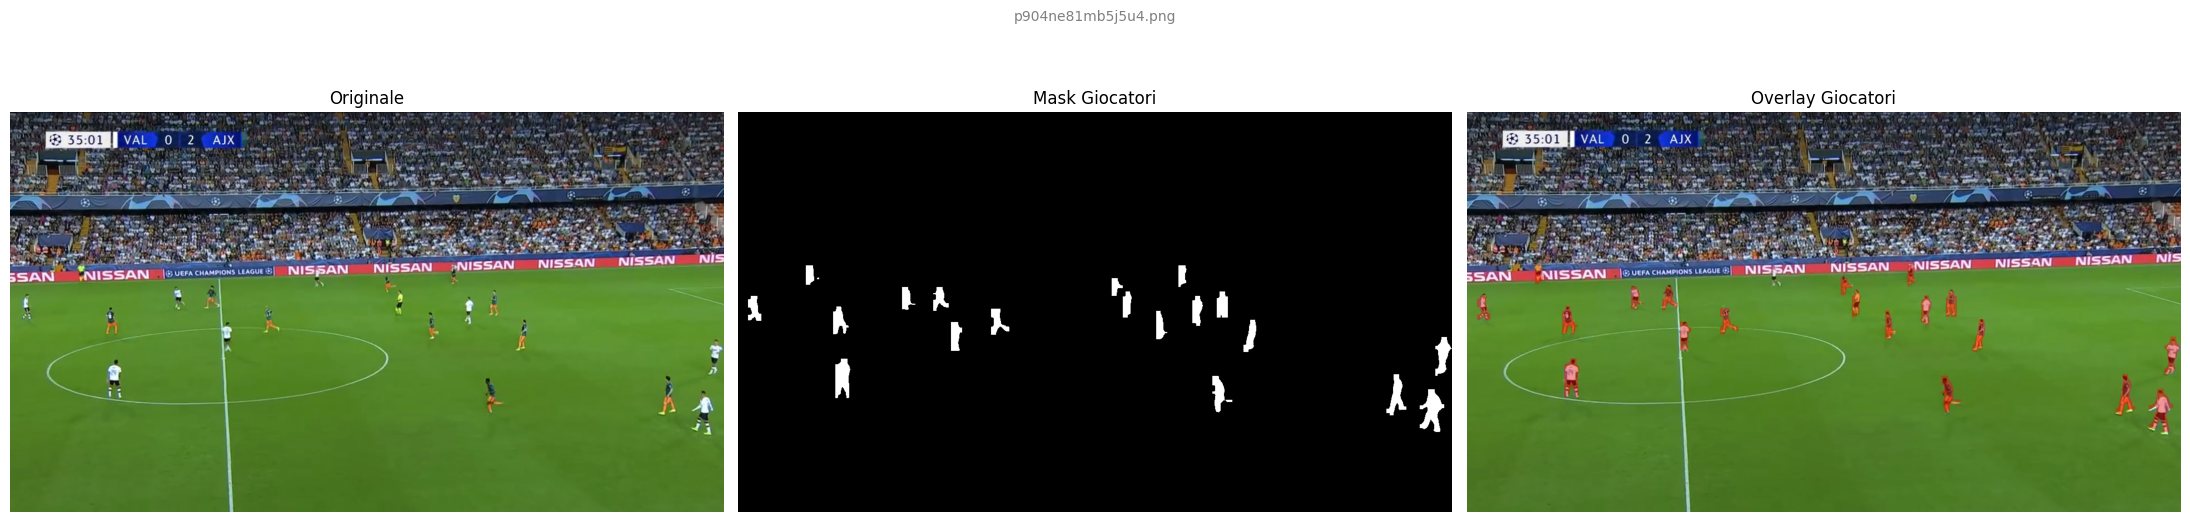

Testato su: p904ne81mb5j5u4.png


In [4]:
def get_players_mask(img_rgb):
    h, w = img_rgb.shape[:2]
    res = person_model(img_rgb, classes=[0], verbose=False, conf=0.3, imgsz=1280)
    players_mask = np.zeros((h, w), dtype=np.uint8)
    if len(res) > 0 and res[0].masks is not None:
        for m in res[0].masks.data.cpu().numpy():
            if m.shape != (h, w):
                m = cv2.resize(m.astype(np.float32), (w, h), interpolation=cv2.INTER_LINEAR)
            players_mask = np.maximum(players_mask, (m > 0.5).astype(np.uint8) * 255)
    return players_mask

# Test visivo
import random
test_dir = BASE / 'datasets' / 'dataset_yolo' / 'images' / 'test'
all_imgs  = list(test_dir.glob('*.jpg')) + list(test_dir.glob('*.png'))

if all_imgs:
    test_img_path = random.choice(all_imgs)
    img     = cv2.imread(str(test_img_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    mask_giocatori = get_players_mask(img_rgb)

    # overlay colorato invece di cmap='gray': più leggibile
    overlay = img_rgb.copy()
    overlay[mask_giocatori > 0] = [255, 0, 0]  # rosso sui giocatori
    blended = cv2.addWeighted(img_rgb, 0.6, overlay, 0.4, 0)

    fig, axes = plt.subplots(1, 3, figsize=(22, 6))
    axes[0].imshow(img_rgb);           axes[0].set_title('Originale');          axes[0].axis('off')
    axes[1].imshow(mask_giocatori, cmap='gray'); axes[1].set_title('Mask Giocatori'); axes[1].axis('off')
    axes[2].imshow(blended);           axes[2].set_title('Overlay Giocatori');  axes[2].axis('off')
    plt.suptitle(test_img_path.name, fontsize=10, color='gray')
    plt.tight_layout()
    plt.show()
    print(f'Testato su: {test_img_path.name}')
else:
    print(f'❌ Nessuna immagine in {test_dir}')